# A-D Wandler

In [281]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt

font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 11}

matplotlib.rc('font', **font)

## Flash Converter

ADC Parameter

In [282]:
u_fsr = 5
n_bits = 4
n_levels = 2 ** n_bits
codes = np.arange(-n_levels/2, n_levels/2)

### Ideale AD Umsetzerkennlinie

In [283]:
# Stufenmittelpunkte
u_mid = np.arange(-u_fsr/2, +u_fsr/2, u_fsr / n_levels)
# Stufenbreite
u_width = np.ones(n_levels) * u_fsr / n_levels
# Umschaltspunkte
u_edge = u_mid + u_width / 2

print(u_mid)
print(u_edge)
print(u_width)

df_ideal = pd.DataFrame({
	'Code': codes,
	'U_mittel': u_mid,
	'U_edge': u_edge,
	'U_width': u_width
})
df_ideal

[-2.5    -2.1875 -1.875  -1.5625 -1.25   -0.9375 -0.625  -0.3125  0.
  0.3125  0.625   0.9375  1.25    1.5625  1.875   2.1875]
[-2.34375 -2.03125 -1.71875 -1.40625 -1.09375 -0.78125 -0.46875 -0.15625
  0.15625  0.46875  0.78125  1.09375  1.40625  1.71875  2.03125  2.34375]
[0.3125 0.3125 0.3125 0.3125 0.3125 0.3125 0.3125 0.3125 0.3125 0.3125
 0.3125 0.3125 0.3125 0.3125 0.3125 0.3125]


,Code,U_mittel,U_edge,U_width
0,-8.0,-2.5000,-2.34375,0.3125
1,-7.0,-2.1875,-2.03125,0.3125
2,-6.0,-1.8750,-1.71875,0.3125
3,-5.0,-1.5625,-1.40625,0.3125
4,-4.0,-1.2500,-1.09375,0.3125
5,-3.0,-0.9375,-0.78125,0.3125
6,-2.0,-0.6250,-0.46875,0.3125
7,-1.0,-0.3125,-0.15625,0.3125
8,0.0,0.0000,0.15625,0.3125
9,1.0,0.3125,0.46875,0.3125


Ausgabe der Idealen Kennlinie

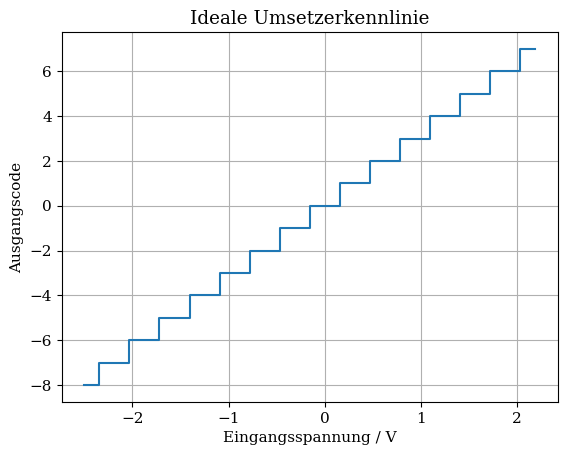

In [284]:
plt.step(u_mid, codes, where='mid')
plt.title('Ideale Umsetzerkennlinie')
plt.xlabel('Eingangsspannung / V')
plt.ylabel('Ausgangscode')
plt.grid(True)
plt.show()

### Reale Messwerte

Schwellen des realen AD Umsetzers messen

In [285]:
# starte bei code -8
u_edge_real = u_edge.copy()[:-1] + 0.1 * np.random.randn(n_levels - 1)

Auswertung

In [286]:
u_width_real = np.array([
	u_edge_real[i+1] - u_edge_real[i]
	for i in range(n_levels-2)
])

u_mid_real = u_edge_real[:-1] + u_width_real / 2

u_real_diff = abs(u_edge_real - u_edge[:-1])
u_width_diff = abs(u_width_real - u_width[1:-1])
u_mid_diff = abs(u_mid_real - u_mid[1:-1])

df_codes = pd.DataFrame({ 'Code': codes })

df_edge = pd.DataFrame({
	'Code': codes[1:],
	'U_edge_real': u_edge_real,
	'U_edge_ideal': u_edge[:-1],
	'U_edge_diff': u_real_diff
})

df_real = pd.DataFrame({
	'Code': codes[1:-1],
	'U_width_real': u_width_real,
	'U_width_ideal': u_width[1:-1],
	'U_width_diff': u_width_diff,
	'U_mittel_real': u_mid_real,
	'U_mittel_ideal': u_mid[1:-1],
	'U_mittel_diff': u_mid_diff
})

# merge dataframes on code
df = pd.merge(df_codes, df_edge, how='left', on='Code')
df = pd.merge(df, df_real, how='left', on='Code')
df

,Code,U_edge_real,U_edge_ideal,U_edge_diff,U_width_real,U_width_ideal,U_width_diff,U_mittel_real,U_mittel_ideal,U_mittel_diff
0,-8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-7.0,-2.416853,-2.34375,0.073103,0.385727,0.3125,0.073227,-2.223989,-2.1875,0.036489
2,-6.0,-2.031126,-2.03125,0.000124,0.359001,0.3125,0.046501,-1.851625,-1.8750,0.023375
3,-5.0,-1.672124,-1.71875,0.046626,0.233113,0.3125,0.079387,-1.555568,-1.5625,0.006932
4,-4.0,-1.439011,-1.40625,0.032761,0.375054,0.3125,0.062554,-1.251484,-1.2500,0.001484
5,-3.0,-1.063957,-1.09375,0.029793,0.378023,0.3125,0.065523,-0.874945,-0.9375,0.062555
6,-2.0,-0.685934,-0.78125,0.095316,0.197753,0.3125,0.114747,-0.587057,-0.6250,0.037943
7,-1.0,-0.488180,-0.46875,0.019430,0.169993,0.3125,0.142507,-0.403184,-0.3125,0.090684
8,0.0,-0.318188,-0.15625,0.161938,0.377272,0.3125,0.064772,-0.129551,0.0000,0.129551
9,1.0,0.059085,0.15625,0.097165,0.534495,0.3125,0.221995,0.326332,0.3125,0.013832


Ausgabe der Realen Kennlinie über der Idealen

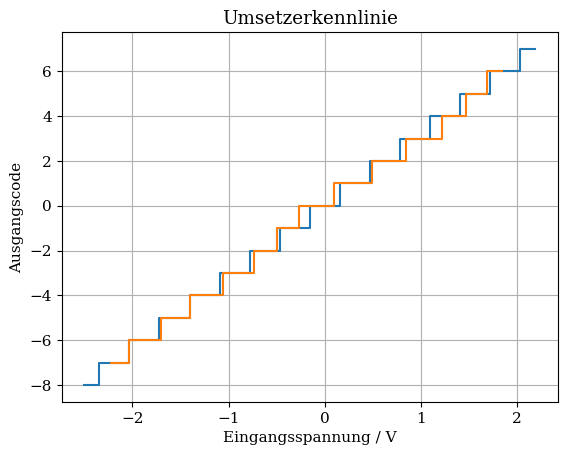

In [287]:
plt.step(u_mid, codes, where='mid')
plt.step(u_mid_real, codes[1:-1], where='mid')
plt.title('Umsetzerkennlinie')
plt.xlabel('Eingangsspannung / V')
plt.ylabel('Ausgangscode')
plt.grid(True)
plt.show()

Tabelle